In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
dir = "/Users/alex/IEEE-CIS_Fraud_Detection_MLOp/"

train_identity = pd.read_csv(dir+"data/raw/train_identity.csv")
train_transaction = pd.read_csv(dir+"data/raw/train_transaction.csv")


## Data Exploration

In [3]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
train_identity.shape

(144233, 41)

In [6]:
train_transaction.shape

(590540, 394)

In [7]:
print(train_transaction["TransactionID"].unique().shape)
print(train_identity["TransactionID"].unique().shape)

(590540,)
(144233,)


### Check duplicates

In [8]:
train_identity.duplicated().sum()

np.int64(0)

In [9]:
train_transaction.duplicated().sum()

np.int64(0)

### Explore NA values

In [10]:
# Print in chunks of 20 columns
nulls = train_transaction.isnull().sum()
for i in range(0, len(nulls), 20):
    print(nulls.iloc[i:i+20])
    print("-" * 50)

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
card1                  0
card2               8933
card3               1565
card4               1577
card5               4259
card6               1571
addr1              65706
addr2              65706
dist1             352271
dist2             552913
P_emaildomain      94456
R_emaildomain     453249
C1                     0
C2                     0
C3                     0
dtype: int64
--------------------------------------------------
C4          0
C5          0
C6          0
C7          0
C8          0
C9          0
C10         0
C11         0
C12         0
C13         0
C14         0
D1       1269
D2     280797
D3     262878
D4     168922
D5     309841
D6     517353
D7     551623
D8     515614
D9     515614
dtype: int64
--------------------------------------------------
D10     76022
D11    279287
D12    525823
D13    528588
D14    528353
D15     89113
M1     2

In [11]:
# Print in chunks of 20 columns
nulls = train_identity.isnull().sum()
for i in range(0, len(nulls), 20):
    print(nulls.iloc[i:i+20])
    print("-" * 50)

TransactionID         0
id_01                 0
id_02              3361
id_03             77909
id_04             77909
id_05              7368
id_06              7368
id_07            139078
id_08            139078
id_09             69307
id_10             69307
id_11              3255
id_12                 0
id_13             16913
id_14             64189
id_15              3248
id_16             14893
id_17              4864
id_18             99120
id_19              4915
dtype: int64
--------------------------------------------------
id_20           4972
id_21         139074
id_22         139064
id_23         139064
id_24         139486
id_25         139101
id_26         139070
id_27         139064
id_28           3255
id_29           3255
id_30          66668
id_31           3951
id_32          66647
id_33          70944
id_34          66428
id_35           3248
id_36           3248
id_37           3248
id_38           3248
DeviceType      3423
dtype: int64
-----------------------

This dataset has plenty of missing values, which would impact our modelling. If a column with over 50% value is missing, that column is meaningless, let's drop the columns with more than 50% missing values.

In [12]:
# train_transaction
# Calculate null counts and percentages
nulls = train_transaction.isnull().sum()
null_percent = (nulls / len(train_transaction)) * 100

# Filter columns with <= 50% null values
cols_to_keep = nulls[null_percent <= 50].index
train_transaction_filtered = train_transaction[cols_to_keep]

# Get null info for the remaining columns
remaining_nulls = train_transaction_filtered.isnull().sum()
remaining_percent = (remaining_nulls / len(train_transaction_filtered)) * 100

# Create a DataFrame for better display
null_info = pd.DataFrame({
    'Column': remaining_nulls.index,
    'Null_Count': remaining_nulls.values,
    'Null_Percentage': remaining_percent.values
})

# Print in chunks of 20 columns
print(f"Remaining columns: {len(null_info)}")
print("=" * 70)
for i in range(0, len(null_info), 20):
    print(null_info.iloc[i:i+20].to_string(index=False))
    print("-" * 70)

Remaining columns: 220
        Column  Null_Count  Null_Percentage
 TransactionID           0         0.000000
       isFraud           0         0.000000
 TransactionDT           0         0.000000
TransactionAmt           0         0.000000
     ProductCD           0         0.000000
         card1           0         0.000000
         card2        8933         1.512683
         card3        1565         0.265012
         card4        1577         0.267044
         card5        4259         0.721204
         card6        1571         0.266028
         addr1       65706        11.126427
         addr2       65706        11.126427
 P_emaildomain       94456        15.994852
            C1           0         0.000000
            C2           0         0.000000
            C3           0         0.000000
            C4           0         0.000000
            C5           0         0.000000
            C6           0         0.000000
-----------------------------------------------------

In [13]:
# train_identity
# Calculate null counts and percentages
nulls = train_identity.isnull().sum()
null_percent = (nulls / len(train_identity)) * 100

# Filter columns with <= 50% null values
cols_to_keep = nulls[null_percent <= 50].index
train_identity_filtered = train_identity[cols_to_keep]

# Get null info for the remaining columns
remaining_nulls = train_identity_filtered.isnull().sum()
remaining_percent = (remaining_nulls / len(train_identity_filtered)) * 100

# Create a DataFrame for better display
null_info = pd.DataFrame({
    'Column': remaining_nulls.index,
    'Null_Count': remaining_nulls.values,
    'Null_Percentage': remaining_percent.values
})

# Print in chunks of 20 columns
print(f"Remaining columns: {len(null_info)}")
print("=" * 70)
for i in range(0, len(null_info), 20):
    print(null_info.iloc[i:i+20].to_string(index=False))
    print("-" * 70)

Remaining columns: 29
       Column  Null_Count  Null_Percentage
TransactionID           0         0.000000
        id_01           0         0.000000
        id_02        3361         2.330257
        id_05        7368         5.108401
        id_06        7368         5.108401
        id_09       69307        48.052110
        id_10       69307        48.052110
        id_11        3255         2.256765
        id_12           0         0.000000
        id_13       16913        11.726165
        id_14       64189        44.503685
        id_15        3248         2.251912
        id_16       14893        10.325654
        id_17        4864         3.372321
        id_19        4915         3.407681
        id_20        4972         3.447200
        id_28        3255         2.256765
        id_29        3255         2.256765
        id_30       66668        46.222432
        id_31        3951         2.739318
----------------------------------------------------------------------
    

Since some of the columns has near 50% missing values, advanced imputation could be implement before modelling. However, we can continue data exploration now.

### Modify data type

In [14]:
train_transaction.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 394 columns):
 #    Column          Non-Null Count   Dtype  
---   ------          --------------   -----  
 0    TransactionID   590540 non-null  int64  
 1    isFraud         590540 non-null  int64  
 2    TransactionDT   590540 non-null  int64  
 3    TransactionAmt  590540 non-null  float64
 4    ProductCD       590540 non-null  object 
 5    card1           590540 non-null  int64  
 6    card2           581607 non-null  float64
 7    card3           588975 non-null  float64
 8    card4           588963 non-null  object 
 9    card5           586281 non-null  float64
 10   card6           588969 non-null  object 
 11   addr1           524834 non-null  float64
 12   addr2           524834 non-null  float64
 13   dist1           238269 non-null  float64
 14   dist2           37627 non-null   float64
 15   P_emaildomain   496084 non-null  object 
 16   R_emaildomain   137291 non-null  obj

In [15]:

# 1. Define column names manually or using string formatting
categorical_cols = [
    "ProductCD",
    "addr1",
    "addr2",
    "P_emaildomain",
    "R_emaildomain",
]

# Add card1 through card6
categorical_cols += [f"card{i}" for i in range(1, 7)]

# Add M1 through M9
categorical_cols += [f"M{i}" for i in range(1, 10)]

# 2. Filter to ensure we only target columns that exist in the DataFrame
existing_cols = [col for col in categorical_cols if col in train_transaction.columns]

# 3. Convert selected columns to 'category'
train_transaction[existing_cols] = train_transaction[existing_cols].astype("category")

# Verification: Check updated data types and memory usage reduction
print(train_transaction[existing_cols].dtypes)
print(f"New total memory usage: {train_transaction.memory_usage().sum() / 1e9:.2f} GB")

ProductCD        category
addr1            category
addr2            category
P_emaildomain    category
R_emaildomain    category
card1            category
card2            category
card3            category
card4            category
card5            category
card6            category
M1               category
M2               category
M3               category
M4               category
M5               category
M6               category
M7               category
M8               category
M9               category
dtype: object
New total memory usage: 1.78 GB


In [16]:
train_identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [17]:

# 1. Define initial non-ranged columns
categorical_cols = ["DeviceType", "DeviceInfo"]

# 2. Add id_12 through id_38
categorical_cols += [f"id_{i:02d}" for i in range(12, 39)]

# 3. Filter to ensure we only target columns that exist in train_identity
existing_cols = [col for col in categorical_cols if col in train_identity.columns]

# 4. Convert selected columns to 'category'
train_identity[existing_cols] = train_identity[existing_cols].astype("category")

# Verification: Check data types for converted columns and updated memory usage
print(train_identity[existing_cols].dtypes)
print(f"New total memory usage: {train_identity.memory_usage().sum() / 1e6:.2f} MB")

DeviceType    category
DeviceInfo    category
id_12         category
id_13         category
id_14         category
id_15         category
id_16         category
id_17         category
id_18         category
id_19         category
id_20         category
id_21         category
id_22         category
id_23         category
id_24         category
id_25         category
id_26         category
id_27         category
id_28         category
id_29         category
id_30         category
id_31         category
id_32         category
id_33         category
id_34         category
id_35         category
id_36         category
id_37         category
id_38         category
dtype: object
New total memory usage: 19.22 MB


### Explore the fraud distribution

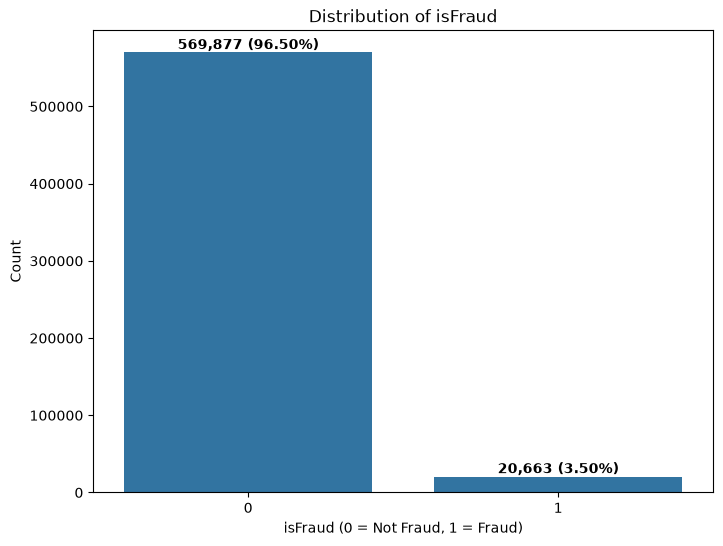

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=train_transaction)
plt.title('Distribution of isFraud')
plt.xlabel('isFraud (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Count')

# Calculate percentages
total = len(train_transaction)
percentages = train_transaction['isFraud'].value_counts(normalize=True).sort_index() * 100

# Add percentage labels on bars
for i, v in enumerate(train_transaction['isFraud'].value_counts().sort_index()):
    plt.text(i, v + 100, f'{v:,} ({percentages[i]:.2f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.show()

### Explore the transaction amount distribution

Transaction Amount Statistics by Fraud Status
            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  

Additional Statistics:
----------------------------------------
isFraud = 0:
  Skewness: 14.67
  Kurtosis: 1158.57
  IQR: 76.03
  Min: 0.25
  Max: 31937.39
----------------------------------------
isFraud = 1:
  Skewness: 5.46
  Kurtosis: 53.09
  IQR: 125.96
  Min: 0.29
  Max: 5191.00
----------------------------------------


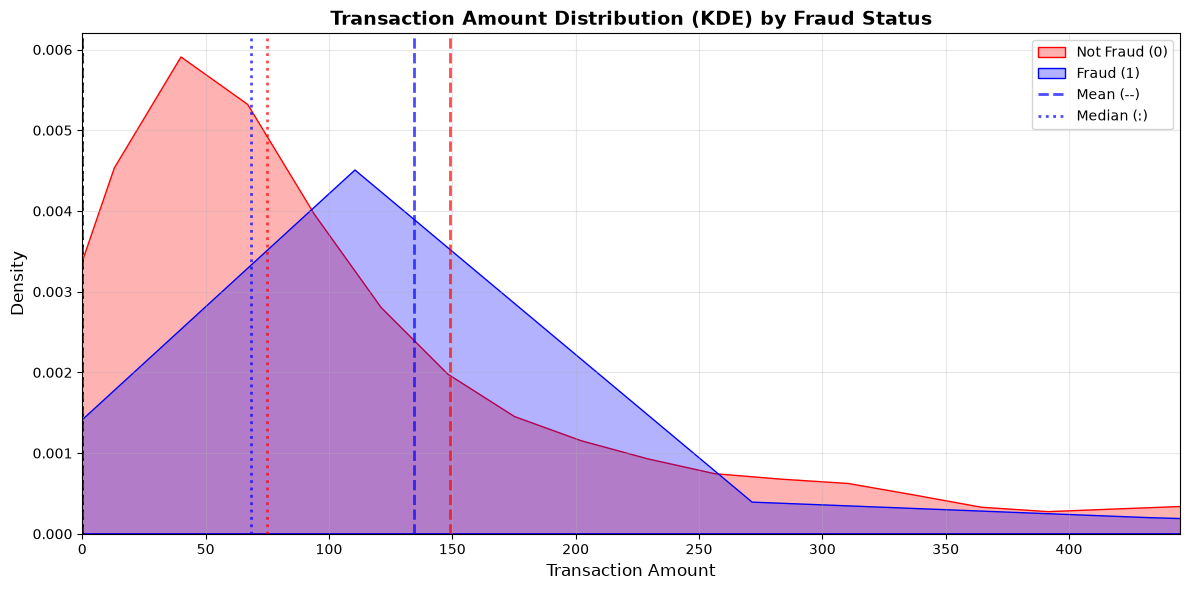

In [19]:
# Calculate and print statistics
stats = train_transaction.groupby('isFraud')['TransactionAmt'].describe()
print("=" * 60)
print("Transaction Amount Statistics by Fraud Status")
print("=" * 60)
print(stats)
print("\nAdditional Statistics:")
print("-" * 40)
for fraud_status in [0, 1]:
    data = train_transaction[train_transaction['isFraud'] == fraud_status]['TransactionAmt']
    print(f"isFraud = {fraud_status}:")
    print(f"  Skewness: {data.skew():.2f}")
    print(f"  Kurtosis: {data.kurtosis():.2f}")
    print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}")
    print(f"  Min: {data.min():.2f}")
    print(f"  Max: {data.max():.2f}")
    print("-" * 40)

# Plot
plt.figure(figsize=(12, 6))

# KDE plots
sns.kdeplot(data=train_transaction, x='TransactionAmt', hue='isFraud', 
            fill=True, alpha=0.3, common_norm=False, palette=['blue', 'red'])

plt.title('Transaction Amount Distribution (KDE) by Fraud Status', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, train_transaction['TransactionAmt'].quantile(0.95))
plt.legend(['Not Fraud (0)', 'Fraud (1)'])
plt.grid(alpha=0.3)

# Add mean and median lines
for fraud_status, color in [(0, 'blue'), (1, 'red')]:
    data = train_transaction[train_transaction['isFraud'] == fraud_status]['TransactionAmt']
    plt.axvline(data.mean(), color=color, linestyle='--', alpha=0.7, linewidth=2)
    plt.axvline(data.median(), color=color, linestyle=':', alpha=0.7, linewidth=2)

# Add legend for lines
plt.axvline(0, color='black', linestyle='--', alpha=0.7, linewidth=2, label='Mean (--)')
plt.axvline(0, color='black', linestyle=':', alpha=0.7, linewidth=2, label='Median (:)')
plt.legend(['Not Fraud (0)', 'Fraud (1)', 'Mean (--)', 'Median (:)'])

plt.tight_layout()
plt.show()

In [20]:
train_transaction_filtered.columns.to_list()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'P_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D10',
 'D11',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M6',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',


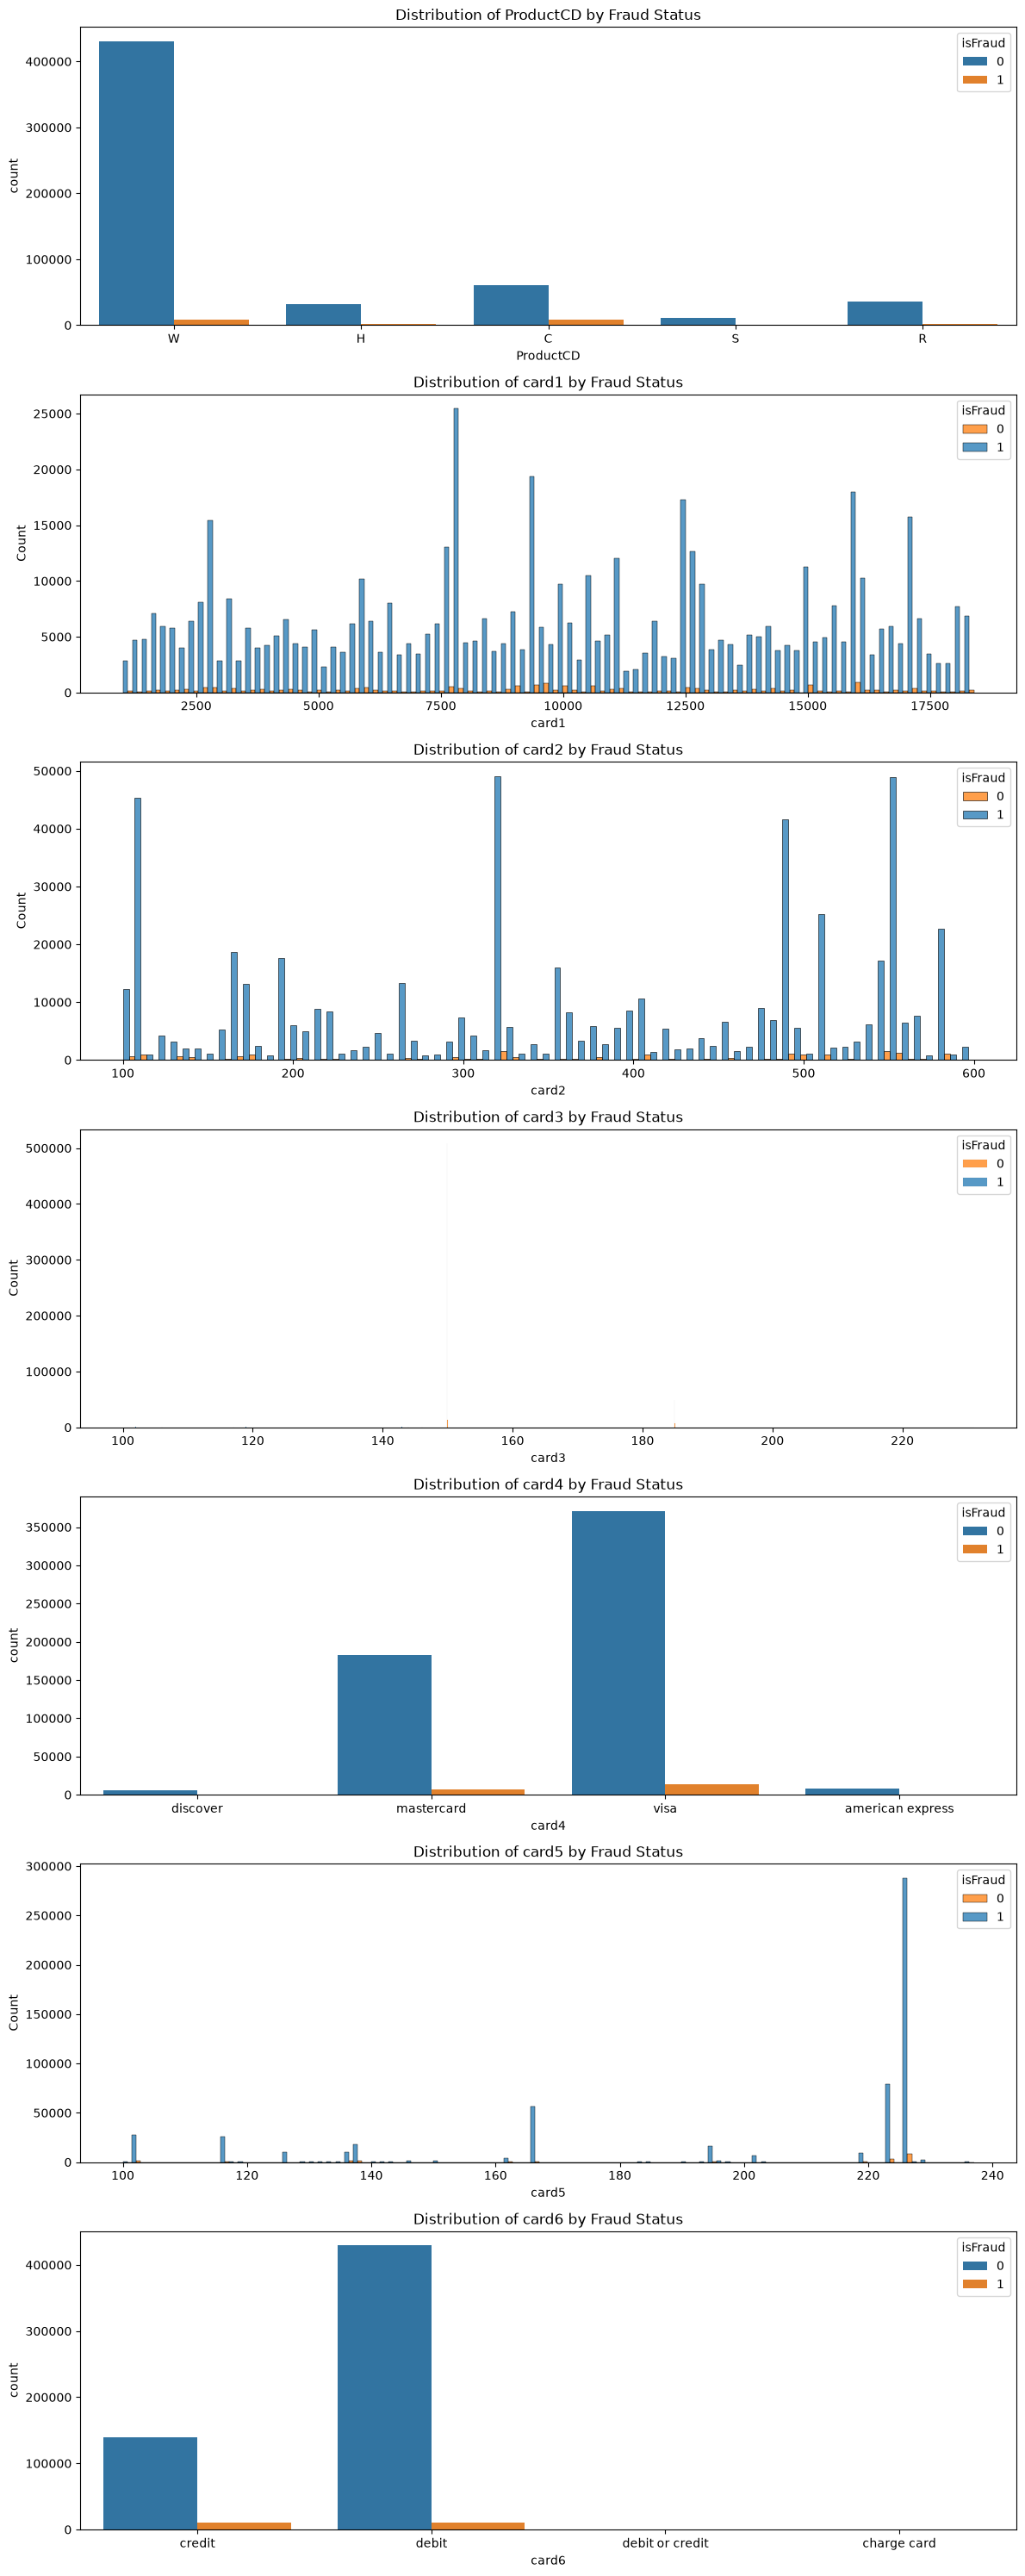

In [21]:


# Assume train_transaction_filtered is already loaded as a pandas DataFrame
df = train_transaction_filtered

# Columns to plot
cols = ['ProductCD'] + [f'card{i}' for i in range(1, 7)]

# Create subplots: 7 rows, 1 column
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(12, 30))

for ax, col in zip(axes, cols):
    # If column is categorical or has few unique values, use countplot
    if df[col].dtype.name in ['object', 'category'] or df[col].nunique() < 20:
        sns.countplot(data=df, x=col, hue='isFraud', ax=ax)
    else:
        # For numeric columns with many values, use histogram
        sns.histplot(data=df, x=col, hue='isFraud', kde=False, multiple='dodge', ax=ax)
    
    ax.set_title(f'Distribution of {col} by Fraud Status')
    ax.legend(title='isFraud', labels=['0', '1'])

plt.tight_layout()
plt.show()

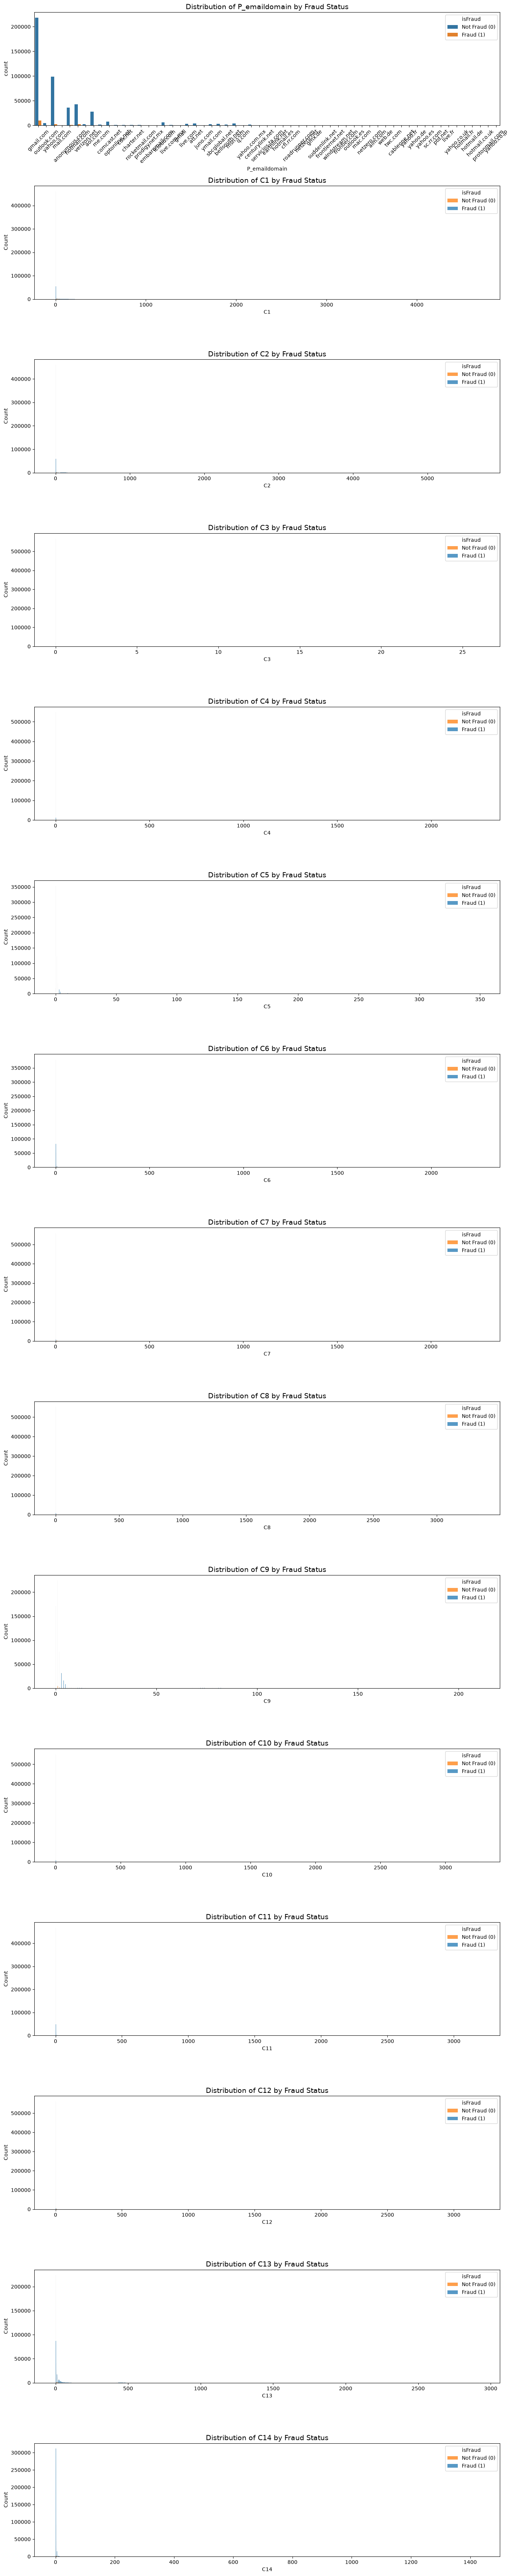

In [22]:

# Assume train_transaction_filtered is already loaded as a pandas DataFrame
df = train_transaction_filtered

# List of columns to plot
cols = ['P_emaildomain'] + [f'C{i}' for i in range(1, 15)]  # 1 + 14 = 15 columns

# Create subplots: 15 rows, 1 column
fig, axes = plt.subplots(nrows=15, ncols=1, figsize=(14, 70))

for ax, col in zip(axes, cols):
    # If column is categorical/text or has few unique values, use countplot
    if df[col].dtype.name in ['object', 'category'] or df[col].nunique() < 20:
        sns.countplot(data=df, x=col, hue='isFraud', ax=ax)
        # Rotate x-labels if they are long or numerous
        ax.tick_params(axis='x', rotation=45)
    else:
        # For numeric columns with many values, use histogram
        sns.histplot(data=df, x=col, hue='isFraud', kde=False, multiple='dodge', ax=ax)
    
    ax.set_title(f'Distribution of {col} by Fraud Status', fontsize=14)
    ax.legend(title='isFraud', labels=['Not Fraud (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()

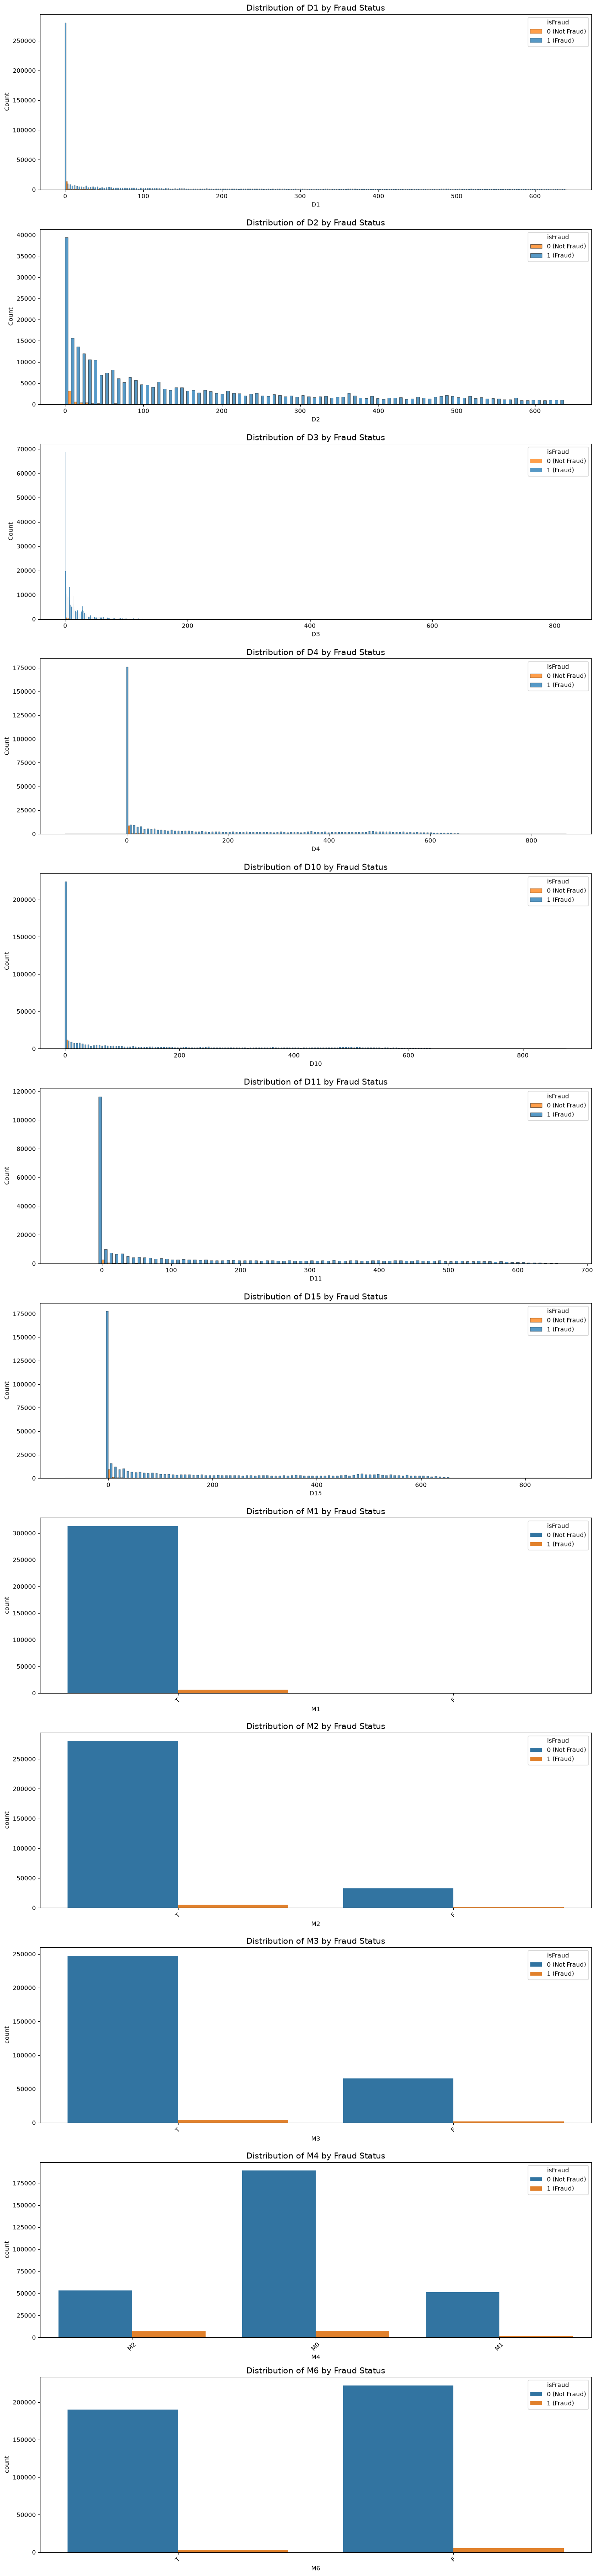

In [23]:

# Assume train_transaction_filtered is already loaded as a pandas DataFrame
df = train_transaction_filtered

# Columns to plot
cols = ['D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6']

# Create subplots: 12 rows, 1 column
fig, axes = plt.subplots(nrows=len(cols), ncols=1, figsize=(14, 60))

for ax, col in zip(axes, cols):
    # If column is categorical/text or has few unique values, use countplot
    if df[col].dtype.name in ['object', 'category'] or df[col].nunique() < 20:
        sns.countplot(data=df, x=col, hue='isFraud', ax=ax)
        ax.tick_params(axis='x', rotation=45)
    else:
        # For numeric columns, use histogram
        sns.histplot(data=df, x=col, hue='isFraud', kde=False, multiple='dodge', ax=ax)
    
    ax.set_title(f'Distribution of {col} by Fraud Status', fontsize=14)
    ax.legend(title='isFraud', labels=['0 (Not Fraud)', '1 (Fraud)'])

plt.tight_layout()
plt.show()

### Persist processed features

The filtering + categorical-dtype logic has been refactored into `ieee_cis_fraud_detection/features.py`.
This cell runs that pipeline (re-loading from `data/raw/`) and saves the processed frames to
`data/processed/` as parquet, which the modeling notebook will load.

- `data/processed/train_transaction_filtered.parquet`
- `data/processed/train_identity_filtered.parquet`

Parquet is used so the `category` dtype is preserved.


In [ ]:
# Build and save the processed features (reuses the refactored package logic)
from ieee_cis_fraud_detection.features import save_train_features

save_train_features()

# Verify the saved files
import pandas as pd
from ieee_cis_fraud_detection.config import PROCESSED_DATA_DIR

for name in ["train_transaction_filtered.parquet", "train_identity_filtered.parquet"]:
    df = pd.read_parquet(PROCESSED_DATA_DIR / name)
    print(f"{name}: {df.shape} | categorical cols: "
          f"{[c for c in df.columns if df[c].dtype.name == 'category']}")
